In [86]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from setuptools.command.rotate import rotate
from torch.utils.data import Dataset, TensorDataset
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader


(Greg Hogg, 2023) Video: https://www.youtube.com/watch?v=q_HS4s1L8UI&t=147s

In [87]:
df = pd.read_csv('../data/combined_output.csv')

df.head()

,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,...,3_day_max,3_day_min,5_day_max,5_day_min,day_of_week,numerical_sentiment,mean_sentiment_probability,percent_positive,percent_negative,percent_neutral
0,2026-01-26,672.36,675.2800,661.2855,665.125,16327378,671.797893,674.715452,660.732652,664.568942,...,675.2800,661.2855,675.2800,644.4450,1,-0.082474,0.797085,0.134021,0.216495,0.649485
1,2026-01-27,672.97,676.8150,664.6600,674.590,13148719,672.407383,676.249169,664.104331,674.026029,...,676.8150,661.2855,676.8150,644.4450,2,0.158879,0.790941,0.299065,0.140187,0.560748
2,2026-01-28,668.73,677.6775,666.1000,674.500,25709600,668.170928,677.110948,665.543127,673.936104,...,677.6775,661.2855,677.6775,661.2855,3,0.170543,0.801010,0.302326,0.131783,0.565891
3,2026-01-29,738.31,744.0000,712.5500,737.430,59852903,737.692758,743.378001,711.954294,736.813493,...,744.0000,664.6600,744.0000,661.2855,4,-0.027027,0.806134,0.209459,0.236486,0.554054
4,2026-01-30,716.50,732.1700,713.5900,727.500,23744573,715.900991,731.557891,712.993424,726.891795,...,744.0000,666.1000,744.0000,661.2855,5,-0.109375,0.837781,0.156250,0.265625,0.578125


In [88]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu:1'

device

'cpu:1'

In [89]:
columns = df.columns

day = 1

df = df.set_index('date')

df['previous_day_numerical_sentiment'] = df['numerical_sentiment'].shift(day)
df['previous_day_mean_sentiment_probability'] = df['mean_sentiment_probability'].shift(day)
df['previous_day_percent_positive'] = df['percent_positive'].shift(day)
df['previous_day_percent_negative'] = df['percent_negative'].shift(day)
df['previous_day_percent_neutral'] = df['percent_neutral'].shift(day)

df = df.drop(columns=['high',
                      'low',
                      'open',
                      'volume',
                      'adjClose',
                      'adjHigh',
                      'adjLow',
                      'adjOpen',
                      'adjVolume',
                      'divCash',
                      'splitFactor',
                      'numerical_sentiment',
                      'mean_sentiment_probability',
                      'percent_positive',
                      'percent_negative',
                      'percent_neutral',])

df.iloc[2]

close                                      6.687300e+02
previous_day_close                         6.729700e+02
previous_day_high                          6.768150e+02
previous_day_low                           6.646600e+02
previous_day_open                          6.745900e+02
previous_day_volume                        1.314872e+07
1_day_max                                  6.776775e+02
1_day_min                                  6.661000e+02
3_day_max                                  6.776775e+02
3_day_min                                  6.612855e+02
5_day_max                                  6.776775e+02
5_day_min                                  6.612855e+02
day_of_week                                3.000000e+00
previous_day_numerical_sentiment           1.588785e-01
previous_day_mean_sentiment_probability    7.909406e-01
previous_day_percent_positive              2.990654e-01
previous_day_percent_negative              1.401869e-01
previous_day_percent_neutral               5.607

[Text(0.5, 0, 'Date'), Text(0, 0.5, 'Closing Price')]

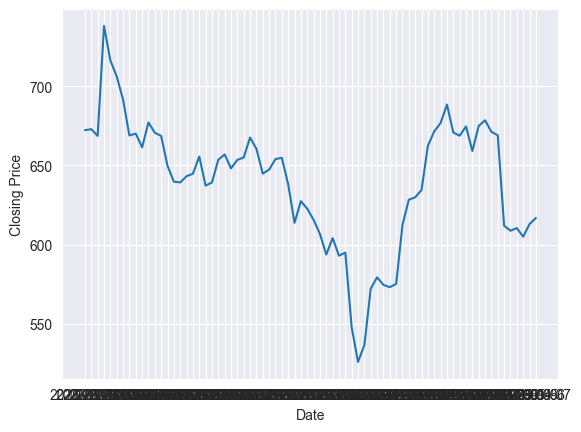

In [90]:
line_graph = sns.lineplot(x='date', y='close', data=df)
line_graph.set(xlabel='Date', ylabel='Closing Price')

In [91]:
df = df.dropna()

In [92]:
from sklearn.preprocessing import MinMaxScaler

scalar = MinMaxScaler(feature_range=(-1,1))

df_as_np_array = scalar.fit_transform(df)

df_as_np_array

array([[ 0.38529564,  0.37955689,  0.3277574 , ..., -0.5918463 ,
        -0.0257732 ,  0.49419735],
       [ 0.34540665,  0.38529564,  0.34277329, ...,  0.4565633 ,
        -0.36915888,  0.18387183],
       [ 1.        ,  0.34540665,  0.35121056, ...,  0.47727273,
        -0.40697674,  0.20186047],
       ...,
       [-0.25452749, -0.20325509, -0.27170457, ..., -0.06225296,
        -0.80434783,  0.80770186],
       [-0.18001787, -0.25452749, -0.26828075, ...,  0.18560606,
         0.03846154,  0.01626374],
       [-0.1430453 , -0.18001787, -0.21349963, ..., -0.1289185 ,
        -0.22413793,  0.39349754]], shape=(71, 18))

In [93]:
X = df_as_np_array[:, 1:]
Y = df_as_np_array[:, 0]

X.shape, Y.shape

((71, 17), (71,))

In [94]:
train_size = int(len(df) * 0.8)


X_train = X[:train_size].reshape((-1, 17, 1))
Y_train = Y[:train_size].reshape((-1, 1))

X_test = X[train_size:].reshape((-1, 17, 1))
Y_test = Y[train_size:].reshape((-1, 1))

X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

((56, 17, 1), (56, 1), (15, 17, 1), (15, 1))

In [95]:
X_train = torch.tensor(X_train).float()
Y_train = torch.tensor(Y_train).float()
X_test = torch.tensor(X_test).float()
Y_test = torch.tensor(Y_test).float()

X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

(torch.Size([56, 17, 1]),
 torch.Size([56, 1]),
 torch.Size([15, 17, 1]),
 torch.Size([15, 1]))

In [96]:
class StockDataset(Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

In [97]:
train_dataset = StockDataset(X_train, Y_train)
test_dataset = StockDataset(X_test, Y_test)

train_dataset.__len__()

56

In [98]:
train_dataloader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=False,
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
)

train_dataloader

In [99]:
for _, batch in enumerate(train_dataloader):
    x_batch, y_batch = batch[0].to(device), batch[1].to(device)
    print(x_batch.shape, y_batch.shape)


torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])


In [100]:
class Net(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        batch_size = x.shape[0]
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

In [101]:
model = Net(1, 32, 2, 1)
model.to(device)
model

Net(
  (lstm): LSTM(1, 32, num_layers=2, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

In [102]:
lr = 1e-3
num_epochs = 300
loss_function = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

for epoch in range(num_epochs):
    optimizer.zero_grad()
    output = model(X_train)
    loss = loss_function(output, Y_train)

    if epoch % 25 == 0:
        # Every 25 epochs
        print(epoch, loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()



0 0.161950021982193
25 0.1369267851114273
50 0.026151563972234726
75 0.022693874314427376
100 0.021044986322522163
125 0.019845789298415184
150 0.018836313858628273
175 0.018206164240837097
200 0.01791037619113922
225 0.017645733430981636
250 0.017321942374110222
275 0.01691228710114956
